In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('Final_df.csv')
grammar = pd.read_csv('grammar_quality_score.csv')
semantic = pd.read_csv('Semantic_scores.csv')
keyword = pd.read_csv('keyword_score.csv')

In [ ]:
df.head()

,Question,Response_Number,Response,Score,Answer
0,What is data science?,R1,Data science is a field that combines statisti...,1.00,Data science is an interdisciplinary field tha...
1,What are the key steps in the data science pro...,R1,The key steps in the data science process incl...,0.95,The key steps typically include problem defini...
2,What is the difference between supervised and ...,R1,Supervised learning uses labeled data to train...,1.00,Supervised learning involves training a model ...
3,Explain the bias-variance tradeoff.,R1,The bias-variance tradeoff is a concept in mac...,1.00,The bias-variance tradeoff is the balance betw...
4,What is feature engineering?,R1,Feature engineering is the process of creating...,1.00,Feature engineering is the process of selectin...


In [ ]:
grammar.head()

,grammar_score
0,0.5
1,1.0
2,1.0
3,1.0
4,1.0


In [ ]:
semantic.head()

,semantic_similarity
0,0.866848
1,0.651658
2,0.915449
3,0.915531
4,0.875637


In [ ]:
keyword.head()

,keyword_score
0,0.176471
1,0.121951
2,0.342105
3,0.346154
4,0.250000


In [ ]:
new_df = pd.concat([semantic, grammar, keyword, df['Score']], axis=1)

In [ ]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2620 entries, 0 to 2619
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   semantic_similarity  2620 non-null   float64
 1   grammar_score        2620 non-null   float64
 2   keyword_score        2620 non-null   float64
 3   Score                2620 non-null   float64
dtypes: float64(4)
memory usage: 82.0 KB


In [ ]:
def get_totalMarks(semantic_score, grammar_score, keyword_score, max_marks = 10):
  semantic_weight = 0.7
  grammar_weight = 0.05
  keyword_weight = 0.25

  # Weighted average
  weighted_score = (semantic_score * semantic_weight +
                      keyword_score * keyword_weight +
                      grammar_score * grammar_weight)

  # Final total score
  total_score = weighted_score * max_marks
  return round(total_score, 2)  # rounding to 2 decimal places

In [ ]:
total_marks = new_df.apply(lambda row: get_totalMarks(row['semantic_similarity'], row['grammar_score'], row['keyword_score'],10), axis=1)

In [ ]:
total_marks

,0
0,6.76
1,5.37
2,7.76
3,7.77
4,7.25
...,...
2615,4.68
2616,3.43
2617,5.25
2618,5.63


In [ ]:
df['Score']*10

,Score
0,10.0
1,9.5
2,10.0
3,10.0
4,10.0
...,...
2615,1.0
2616,4.0
2617,10.0
2618,3.0


In [ ]:

from sklearn.metrics import mean_absolute_error
actual_score = df['Score']*10
predicted_score = total_marks

mae = mean_absolute_error(actual_score, predicted_score)
print("Absolute Error:", mae)

Absolute Error: 3.4353244274809156


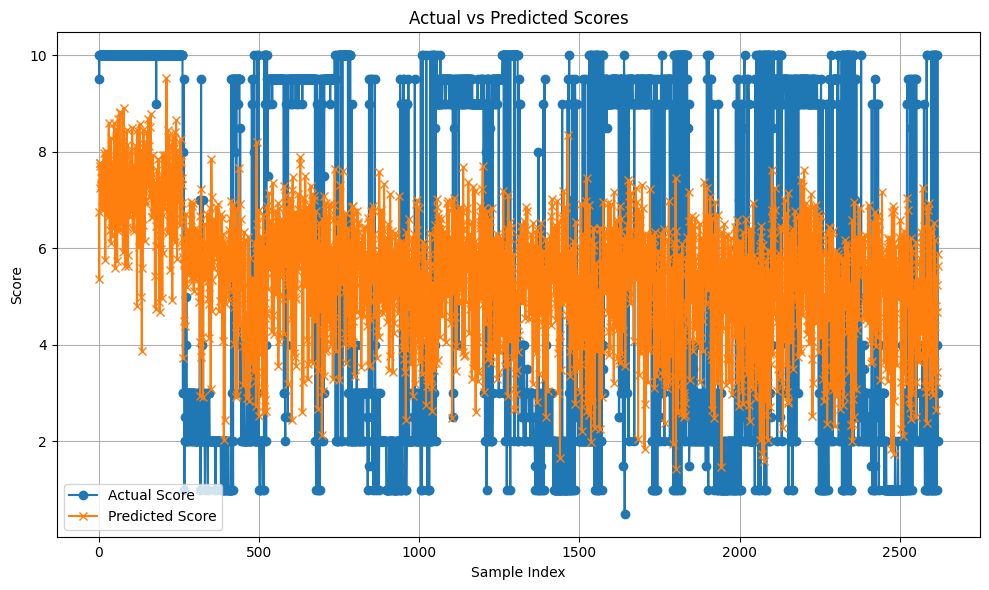

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(actual_score, label='Actual Score', marker='o')
plt.plot(predicted_score, label='Predicted Score', marker='x')
plt.title('Actual vs Predicted Scores')
plt.xlabel('Sample Index')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
